# Import

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from pyspark.ml.evaluation import (BinaryClassificationEvaluator,MulticlassClassificationEvaluator)

# Konfigurasi


## Load Data

In [2]:
spark = SparkSession.builder \
    .appName("FraudClassification-Basic") \
    .master("local[2]") \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "2g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark

# Proses

In [3]:
df = spark.read.parquet(
    "hdfs://namenode:9000/data/processed/fintech/fraudTrain_clean"
)
df.printSchema()

root
 |-- cc_num: long (nullable = true)
 |-- merchant: string (nullable = true)
 |-- category: string (nullable = true)
 |-- amt: double (nullable = true)
 |-- first: string (nullable = true)
 |-- last: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- street: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- zip: integer (nullable = true)
 |-- lat: double (nullable = true)
 |-- long: double (nullable = true)
 |-- city_pop: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- trans_num: string (nullable = true)
 |-- unix_time: integer (nullable = true)
 |-- merch_lat: double (nullable = true)
 |-- merch_long: double (nullable = true)
 |-- is_fraud: integer (nullable = true)
 |-- day_of_month: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- age: long (nullable = true)
 |-- distance: double (nullabl

## Sampling Data

In [4]:
df_sample  = df.sample(
    fraction=0.5,
    seed=42
)
print("Jumlah data sample:", df.count())


Jumlah data sample: 1296675


## Feature Seelection

In [5]:
feature_columns = [
    "amt",
    "age",
    "hour",
    "day_of_week",
    "is_weekend"
]

target_column = "is_fraud"
df_selected  = (df_sample.select(feature_columns + [target_column]))
df_selected.show(2)

+------+---+----+-----------+----------+--------+
|   amt|age|hour|day_of_week|is_weekend|is_fraud|
+------+---+----+-----------+----------+--------+
|242.56| 43|   0|          1|         1|       0|
| 53.63| 32|   0|          1|         1|       0|
+------+---+----+-----------+----------+--------+
only showing top 2 rows



## Vector Assembler

In [6]:
assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features",
)

df_featured  = assembler.transform(df_selected)
df_featured.select("features", "is_fraud").show(5, truncate=False)

+-------------------------+--------+
|features                 |is_fraud|
+-------------------------+--------+
|[242.56,43.0,0.0,1.0,1.0]|0       |
|[53.63,32.0,0.0,1.0,1.0] |0       |
|[72.66,24.0,0.0,1.0,1.0] |0       |
|[79.45,49.0,0.0,1.0,1.0] |0       |
|[122.85,29.0,0.0,1.0,1.0]|0       |
+-------------------------+--------+
only showing top 5 rows



In [7]:
df_final = df_featured.select("features","is_fraud")
df_final.show(3)

+--------------------+--------+
|            features|is_fraud|
+--------------------+--------+
|[242.56,43.0,0.0,...|       0|
|[53.63,32.0,0.0,1...|       0|
|[72.66,24.0,0.0,1...|       0|
+--------------------+--------+
only showing top 3 rows



## Train Test Split

In [8]:
train, test = df_final.randomSplit(
    [0.8, 0.2],
    seed=42
)


In [9]:
train.groupBy("is_fraud").count().show()

+--------+------+
|is_fraud| count|
+--------+------+
|       1|  2942|
|       0|516261|
+--------+------+



In [10]:
test.groupBy("is_fraud").count().show()


+--------+------+
|is_fraud| count|
+--------+------+
|       1|   783|
|       0|129197|
+--------+------+



## Training model

In [11]:
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="is_fraud",
    numTrees=5,
    maxDepth=5,
    seed=42
)

rf_model = rf.fit(train)
rf_model

RandomForestClassificationModel: uid=RandomForestClassifier_41e1a00752e9, numTrees=5, numClasses=2, numFeatures=5

## Evaluasi

In [12]:
pred_rf = rf_model.transform(test)
pred_rf.select("is_fraud","prediction","probability").show(5, truncate=False)

+--------+----------+-----------------------------------------+
|is_fraud|prediction|probability                              |
+--------+----------+-----------------------------------------+
|0       |0.0       |[0.9975716571482233,0.002428342851776689]|
|0       |0.0       |[0.9954291927858889,0.004570807214111057]|
|0       |0.0       |[0.9975716571482233,0.002428342851776689]|
|0       |0.0       |[0.9975063230104814,0.002493676989518676]|
|0       |0.0       |[0.9975063230104814,0.002493676989518676]|
+--------+----------+-----------------------------------------+
only showing top 5 rows



In [13]:
accuracy_eval = MulticlassClassificationEvaluator(
    labelCol="is_fraud",
    predictionCol="prediction",
    metricName="accuracy"
)

precision_eval = MulticlassClassificationEvaluator(
    labelCol="is_fraud",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

recall_eval = MulticlassClassificationEvaluator(
    labelCol="is_fraud",
    predictionCol="prediction",
    metricName="weightedRecall"
)

f1_eval = MulticlassClassificationEvaluator(
    labelCol="is_fraud",
    predictionCol="prediction",
    metricName="f1"
)

pr_eval = BinaryClassificationEvaluator(
    labelCol="is_fraud",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderPR"
)

roc_eval = BinaryClassificationEvaluator(
    labelCol="is_fraud",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)


In [14]:
accuracy = accuracy_eval.evaluate(pred_rf)
precision = precision_eval.evaluate(pred_rf)
recall = recall_eval.evaluate(pred_rf)
f1_score = f1_eval.evaluate(pred_rf)


pr_auc = pr_eval.evaluate(pred_rf)
roc_auc = roc_eval.evaluate(pred_rf)

## Output

In [15]:
print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1 Score       : {f1_score:.4f}")
print(f"PR AUC         : {pr_auc:.4f}")
print(f"ROC AUC        : {roc_auc:.4f}")

Accuracy       : 0.9953
Precision      : 0.9948
Recall         : 0.9953
F1 Score       : 0.9941
PR AUC         : 0.5135
ROC AUC        : 0.9194


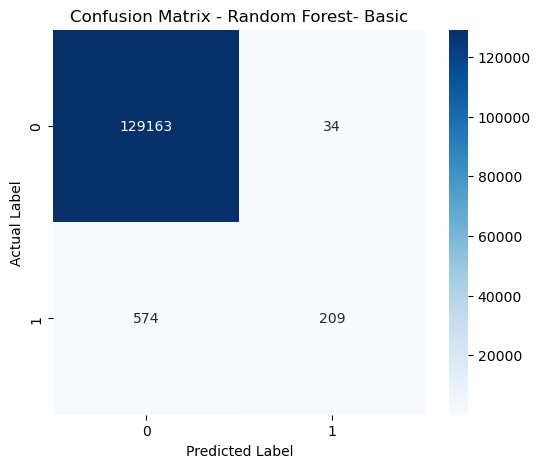

In [16]:
pred_pd = pred_rf.select("is_fraud","prediction").toPandas()

cm = confusion_matrix(
    pred_pd["is_fraud"],
    pred_pd["prediction"]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest- Basic")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [18]:
print(classification_report(
        pred_pd["is_fraud"],
        pred_pd["prediction"]
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    129197
           1       0.86      0.27      0.41       783

    accuracy                           1.00    129980
   macro avg       0.93      0.63      0.70    129980
weighted avg       0.99      1.00      0.99    129980



In [19]:
pred_rf.select("prediction","probability","is_fraud").write.mode("overwrite").parquet("hdfs://namenode:9000/data/analytics/fintech/fraud_prediction_basic")